#  Long/Short Strategy Simulation 

Using Momentum Factor to find 3 long Stocks and 3 Short stocks for holding 10 Business Days


Using 8.alpha_factor_engineering 's Output csv for this

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\chira\Quant_Python_Research\8.nifty_alpha_factors_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6425 entries, 0 to 6424
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            6425 non-null   datetime64[ns]
 1   Stock           6425 non-null   object        
 2   Open            6425 non-null   float64       
 3   High            6425 non-null   float64       
 4   Low             6425 non-null   float64       
 5   Close           6425 non-null   float64       
 6   Volume          6425 non-null   float64       
 7   Momentum_20d    6225 non-null   float64       
 8   Daily_Return    6415 non-null   float64       
 9   Volatility_20d  6225 non-null   float64       
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 502.1+ KB


In [4]:
# Preparing container for strategy results

results = []

# Unique dates , sorted
dates = sorted(df["Date"].unique())

# Simulate every 10th date to avoid overlapping holding
# i = 20 because we need Momentum_20d values to exist and the first 19 would be NaN
# 
for i in range(20, len(dates) - 10, 10):
    date = dates[i]
    next_date = dates[i + 10]

    # Filtering snapshot for current date
    snapshot = df[df["Date"] == date].dropna(subset = ["Momentum_20d"])

    # Top 3 = Long, Bottom 3 = Short
    long_stocks = snapshot.sort_values("Momentum_20d", ascending = False).head(3)["Stock"]
    short_stocks = snapshot.sort_values("Momentum_20d", ascending = True).head(3)["Stock"]

    # Getting prices for entry and exit
    entry_prices = df[(df["Date"] == date) & (df["Stock"].isin(long_stocks.tolist() + short_stocks.tolist()))]
    exit_prices = df[(df["Date"] == next_date) & (df["Stock"].isin(long_stocks.tolist() + short_stocks.tolist()))]

    # Merge by Stock
    merged = pd.merge(
        entry_prices[["Stock", "Close"]],
        exit_prices[["Stock", "Close"]],
        on = "Stock",
        suffixes = ("_entry", "_exit")
    )

    # Marking direction: +1 for long, –1 for short
    merged["Direction"] = merged["Stock"].apply(lambda x: 1 if x in long_stocks.values else -1 )

    # Computing each stock’s trade return 
    merged['Return'] = merged['Direction'] * (merged['Close_exit'] - merged['Close_entry']) / merged['Close_entry']


    # Saving the *average* return of this 6‑stock basket
    results.append({
        "Date" : date,
        "next_date" : next_date,
        "Strategy_Return" : merged["Return"].mean(),
        "Long_Stocks": ', '.join(long_stocks.values),
        "Short_Stocks": ', '.join(short_stocks.values)
    })

# Turning results list into a tidy table.
strategy_df = pd.DataFrame(results)

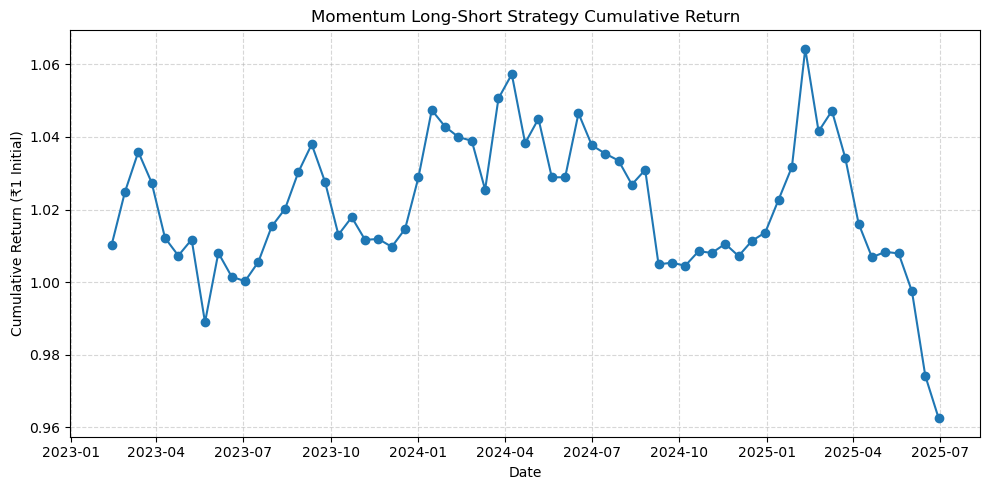

In [5]:
# Calculate cumulative return
strategy_df['Cumulative_Return'] = (1 + strategy_df['Strategy_Return']).cumprod()

# Plot it
plt.figure(figsize=(10, 5))
plt.plot(strategy_df['next_date'], strategy_df['Cumulative_Return'], marker='o')
plt.title("Momentum Long-Short Strategy Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (₹1 Initial)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
strategy_df[['Date', 'Long_Stocks', 'Short_Stocks', 'Strategy_Return']].tail(3)

,Date,Long_Stocks,Short_Stocks,Strategy_Return
60,2025-05-19,"KOTAKBANK, HDFCBANK, RELIANCE","ASIANPAINT, INFY, TCS",-0.010384
61,2025-06-02,"RELIANCE, HDFCBANK, ICICIBANK","KOTAKBANK, LT, ASIANPAINT",-0.023327
62,2025-06-16,"ITC, TCS, INFY","LT, HDFCBANK, ASIANPAINT",-0.011969


In [7]:
strategy_df.to_csv("9.momentum_strategy_returns.csv", index=False)

Signal filtering

In [8]:
# 📦 Step 1: Prepare a new container for filtered strategy results
filtered_results = []

# ✅ Get sorted list of dates
dates = sorted(df["Date"].unique())

# 🔁 Loop through dates every 10 days (after 20th to ensure Momentum exists)
for i in range(20, len(dates) - 10, 10):
    date = dates[i]
    next_date = dates[i + 10]


    # Only this block is diffrernt than the previous, aprat from that everything is same with just some minor name changes
##################################################################################################
    
    # 🧹 Filter snapshot for this date with non-null Momentum & Volatility
    snapshot = df[df["Date"] == date].dropna(subset=["Momentum_20d", "Volatility_20d"])

    # ✂️ Apply volatility filter (remove top 25% most volatile)
    vol_threshold = snapshot["Volatility_20d"].quantile(0.75)
    snapshot = snapshot[snapshot["Volatility_20d"] <= vol_threshold]


#################################################################################################

    # ✅ Select long/short stocks by Momentum within safe volatility
    long_stocks = snapshot.sort_values("Momentum_20d", ascending=False).head(3)["Stock"]
    short_stocks = snapshot.sort_values("Momentum_20d", ascending=True).head(3)["Stock"]

    # 🎯 Get entry/exit prices
    entry_prices = df[(df["Date"] == date) & (df["Stock"].isin(long_stocks.tolist() + short_stocks.tolist()))]
    exit_prices = df[(df["Date"] == next_date) & (df["Stock"].isin(long_stocks.tolist() + short_stocks.tolist()))]

    # 🔗 Merge entry/exit by Stock
    merged = pd.merge(
        entry_prices[["Stock", "Close"]],
        exit_prices[["Stock", "Close"]],
        on="Stock",
        suffixes=("_entry", "_exit")
    )

    # ➕➖ Mark direction
    merged["Direction"] = merged["Stock"].apply(lambda x: 1 if x in long_stocks.values else -1)

    # 📈 Calculate individual trade return
    merged["Return"] = merged["Direction"] * (merged["Close_exit"] - merged["Close_entry"]) / merged["Close_entry"]

    # 📝 Save average return and tickers
    filtered_results.append({
        "Date": date,
        "next_date": next_date,
        "Strategy_Return": merged["Return"].mean(),
        "Long_Stocks": ", ".join(long_stocks.values),
        "Short_Stocks": ", ".join(short_stocks.values)
    })

# ✅ Convert to DataFrame
strategy_filtered_df = pd.DataFrame(filtered_results)

# 📊 Compute cumulative return
strategy_filtered_df["Cumulative_Return"] = (1 + strategy_filtered_df["Strategy_Return"]).cumprod()


Plotting Raw vs Filtered Strategy

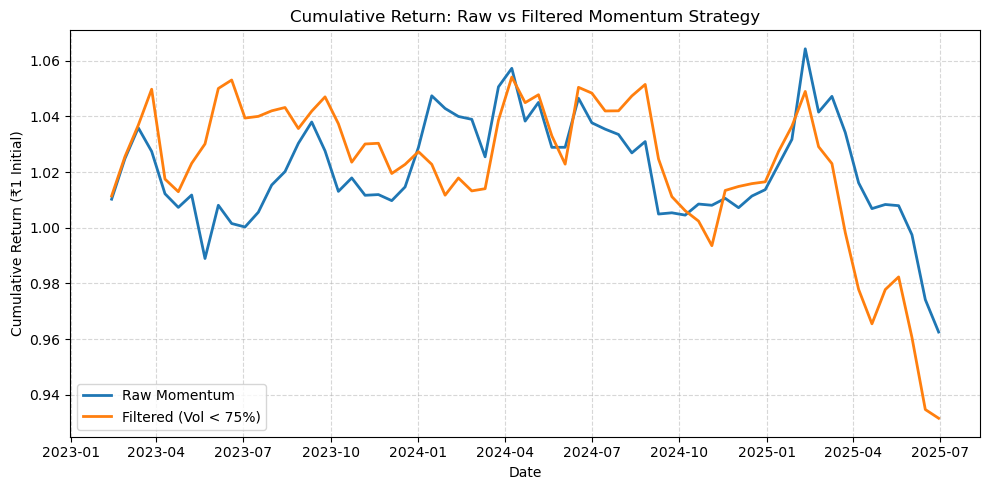

In [9]:
plt.figure(figsize = (10, 5))

# Plotting original momentum strategy , ({Pasted from the above graph code)
plt.plot(strategy_df['next_date'], strategy_df['Cumulative_Return'], label = "Raw Momentum", linewidth = 2)

# Plotting Volatility-filtered momentum strategy
plt.plot(strategy_filtered_df["next_date"], strategy_filtered_df["Cumulative_Return"], label = "Filtered (Vol < 75%)", linewidth = 2)

plt.title("Cumulative Return: Raw vs Filtered Momentum Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (₹1 Initial)")
plt.legend()
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.tight_layout()

plt.show()

In [11]:
strategy_filtered_df.to_csv("9.momentum_strategy_filtered_returns.csv")